# Сравнение TF-IDF baseline-моделей с mBERT

Раздел 2.3.6 ВКР: оценить, какую часть качества обеспечивает классический подход
(TF-IDF + RandomForest / LogisticRegression) и какой прирост даёт трансформер.

Бейзлайны обучаются ТОЛЬКО на v4-записях (4715 шт.) — это «честный» baseline
без двухэтапной стратегии.

In [1]:
import sys
from pathlib import Path

ROOT = Path('.').resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import json
import math
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.evaluation import (
    BASE_VECTOR_METRICS,
    evaluate_baseline,
    train_tfidf_logreg,
    train_tfidf_random_forest_v4_only,
)

train_df = pd.read_parquet(ROOT / 'data/processed/train.parquet')
test_df  = pd.read_parquet(ROOT / 'data/processed/test.parquet')
print('train rows:', len(train_df), '| v4:', train_df['cvss_v4_vector'].notna().sum())
print('test  rows:', len(test_df),  '| v4:', test_df['cvss_v4_vector'].notna().sum())

train rows: 122913 | v4: 4715
test  rows: 26348 | v4: 972


## 1. TF-IDF + RandomForest (v4-only train)

In [2]:
t0 = time.time()
rf_model = train_tfidf_random_forest_v4_only(train_df, n_estimators=200)
rf_train_time = time.time() - t0
print(f'Обучение RF: {rf_train_time:.1f} сек')

rf_result = evaluate_baseline(rf_model, test_df)
print('Aggregated:', rf_result['aggregated'])

Обучение RF: 6.4 сек


Aggregated: {'macro_f1': 0.6904925218855437, 'vector_accuracy': 0.43930041152263377, 'samples_evaluated': 972}


## 2. TF-IDF + LogisticRegression

In [3]:
v4_only = train_df[train_df['cvss_v4_vector'].notna()].reset_index(drop=True)

t0 = time.time()
lr_model = train_tfidf_logreg(v4_only, max_iter=1000)
lr_train_time = time.time() - t0
print(f'Обучение LogReg: {lr_train_time:.1f} сек')

lr_result = evaluate_baseline(lr_model, test_df)
print('Aggregated:', lr_result['aggregated'])

Обучение LogReg: 2.1 сек
Aggregated: {'macro_f1': 0.65281357134567, 'vector_accuracy': 0.39300411522633744, 'samples_evaluated': 972}


## 3. mBERT — берём ранее сохранённые результаты

`reports/test_evaluation.json` — результат двухэтапного обучения (Stage 1 + Stage 2).
Stage-2-only эксперимент в этом проекте не проводился, поэтому в таблице
для него — `—`. Двухэтапная стратегия и есть рекомендуемая (CLAUDE.md, раздел
«Двухэтапная стратегия обучения»).

In [4]:
mbert_path = ROOT / 'reports/test_evaluation.json'
if mbert_path.exists():
    mbert = json.loads(mbert_path.read_text(encoding='utf-8'))
    mbert_agg = mbert['aggregated']
    mbert_per_metric = {m: mbert['per_metric'][m]['f1_macro'] for m in BASE_VECTOR_METRICS}
    print('Aggregated mBERT (Stage1+Stage2):', mbert_agg)
else:
    mbert_agg = None
    mbert_per_metric = {}
    print('test_evaluation.json не найден — mBERT строка останется пустой')

Aggregated mBERT (Stage1+Stage2): {'macro_f1': 0.7090421303484028, 'vector_accuracy': 0.3991769547325103, 'metrics_correct_avg': 9.390946502057613, 'score_mae': 1.1724279835390945, 'score_rmse': 1.9848292936932588, 'severity_accuracy': 0.6738683127572016, 'severity_within_one': 0.9207818930041153, 'samples_evaluated': 972, 'samples_scored': 972}


## Сводная таблица

In [5]:
def _is_missing(v):
    return v is None or (isinstance(v, float) and math.isnan(v))

def fmt(v):
    return '—' if _is_missing(v) else f'{v:.4f}'

def fmt_time(v):
    return '—' if _is_missing(v) else f'{v:.1f} сек'

rows = [
    {
        'Модель': 'TF-IDF + RandomForest',
        'Macro-F1': rf_result['aggregated']['macro_f1'],
        'Vector Accuracy': rf_result['aggregated']['vector_accuracy'],
        'Время обучения': rf_train_time,
    },
    {
        'Модель': 'TF-IDF + LogReg',
        'Macro-F1': lr_result['aggregated']['macro_f1'],
        'Vector Accuracy': lr_result['aggregated']['vector_accuracy'],
        'Время обучения': lr_train_time,
    },
    {
        'Модель': 'mBERT (Stage 2 only)',
        'Macro-F1': None,
        'Vector Accuracy': None,
        'Время обучения': None,
    },
    {
        'Модель': 'mBERT (Stage 1+Stage 2)',
        'Macro-F1': mbert_agg['macro_f1'] if mbert_agg else None,
        'Vector Accuracy': mbert_agg['vector_accuracy'] if mbert_agg else None,
        'Время обучения': None,
    },
]
summary = pd.DataFrame(rows)
summary_pretty = pd.DataFrame({
    'Модель': summary['Модель'],
    'Macro-F1': [fmt(v) for v in summary['Macro-F1']],
    'Vector Accuracy': [fmt(v) for v in summary['Vector Accuracy']],
    'Время обучения': [fmt_time(v) for v in summary['Время обучения']],
})
print(summary_pretty.to_string(index=False))

out_csv = ROOT / 'reports/baseline_comparison.csv'
summary.to_csv(out_csv, index=False, encoding='utf-8')
print('\nСохранено:', out_csv)

                 Модель Macro-F1 Vector Accuracy Время обучения
  TF-IDF + RandomForest   0.6905          0.4393        6.4 сек
        TF-IDF + LogReg   0.6528          0.3930        2.1 сек
   mBERT (Stage 2 only)        —               —              —
mBERT (Stage 1+Stage 2)   0.7090          0.3992              —

Сохранено: C:\Users\Артём\Desktop\diplom\reports\baseline_comparison.csv


## Bar chart F1 по метрикам

Сохранено: C:\Users\Артём\Desktop\diplom\reports\figures\baseline_comparison.png


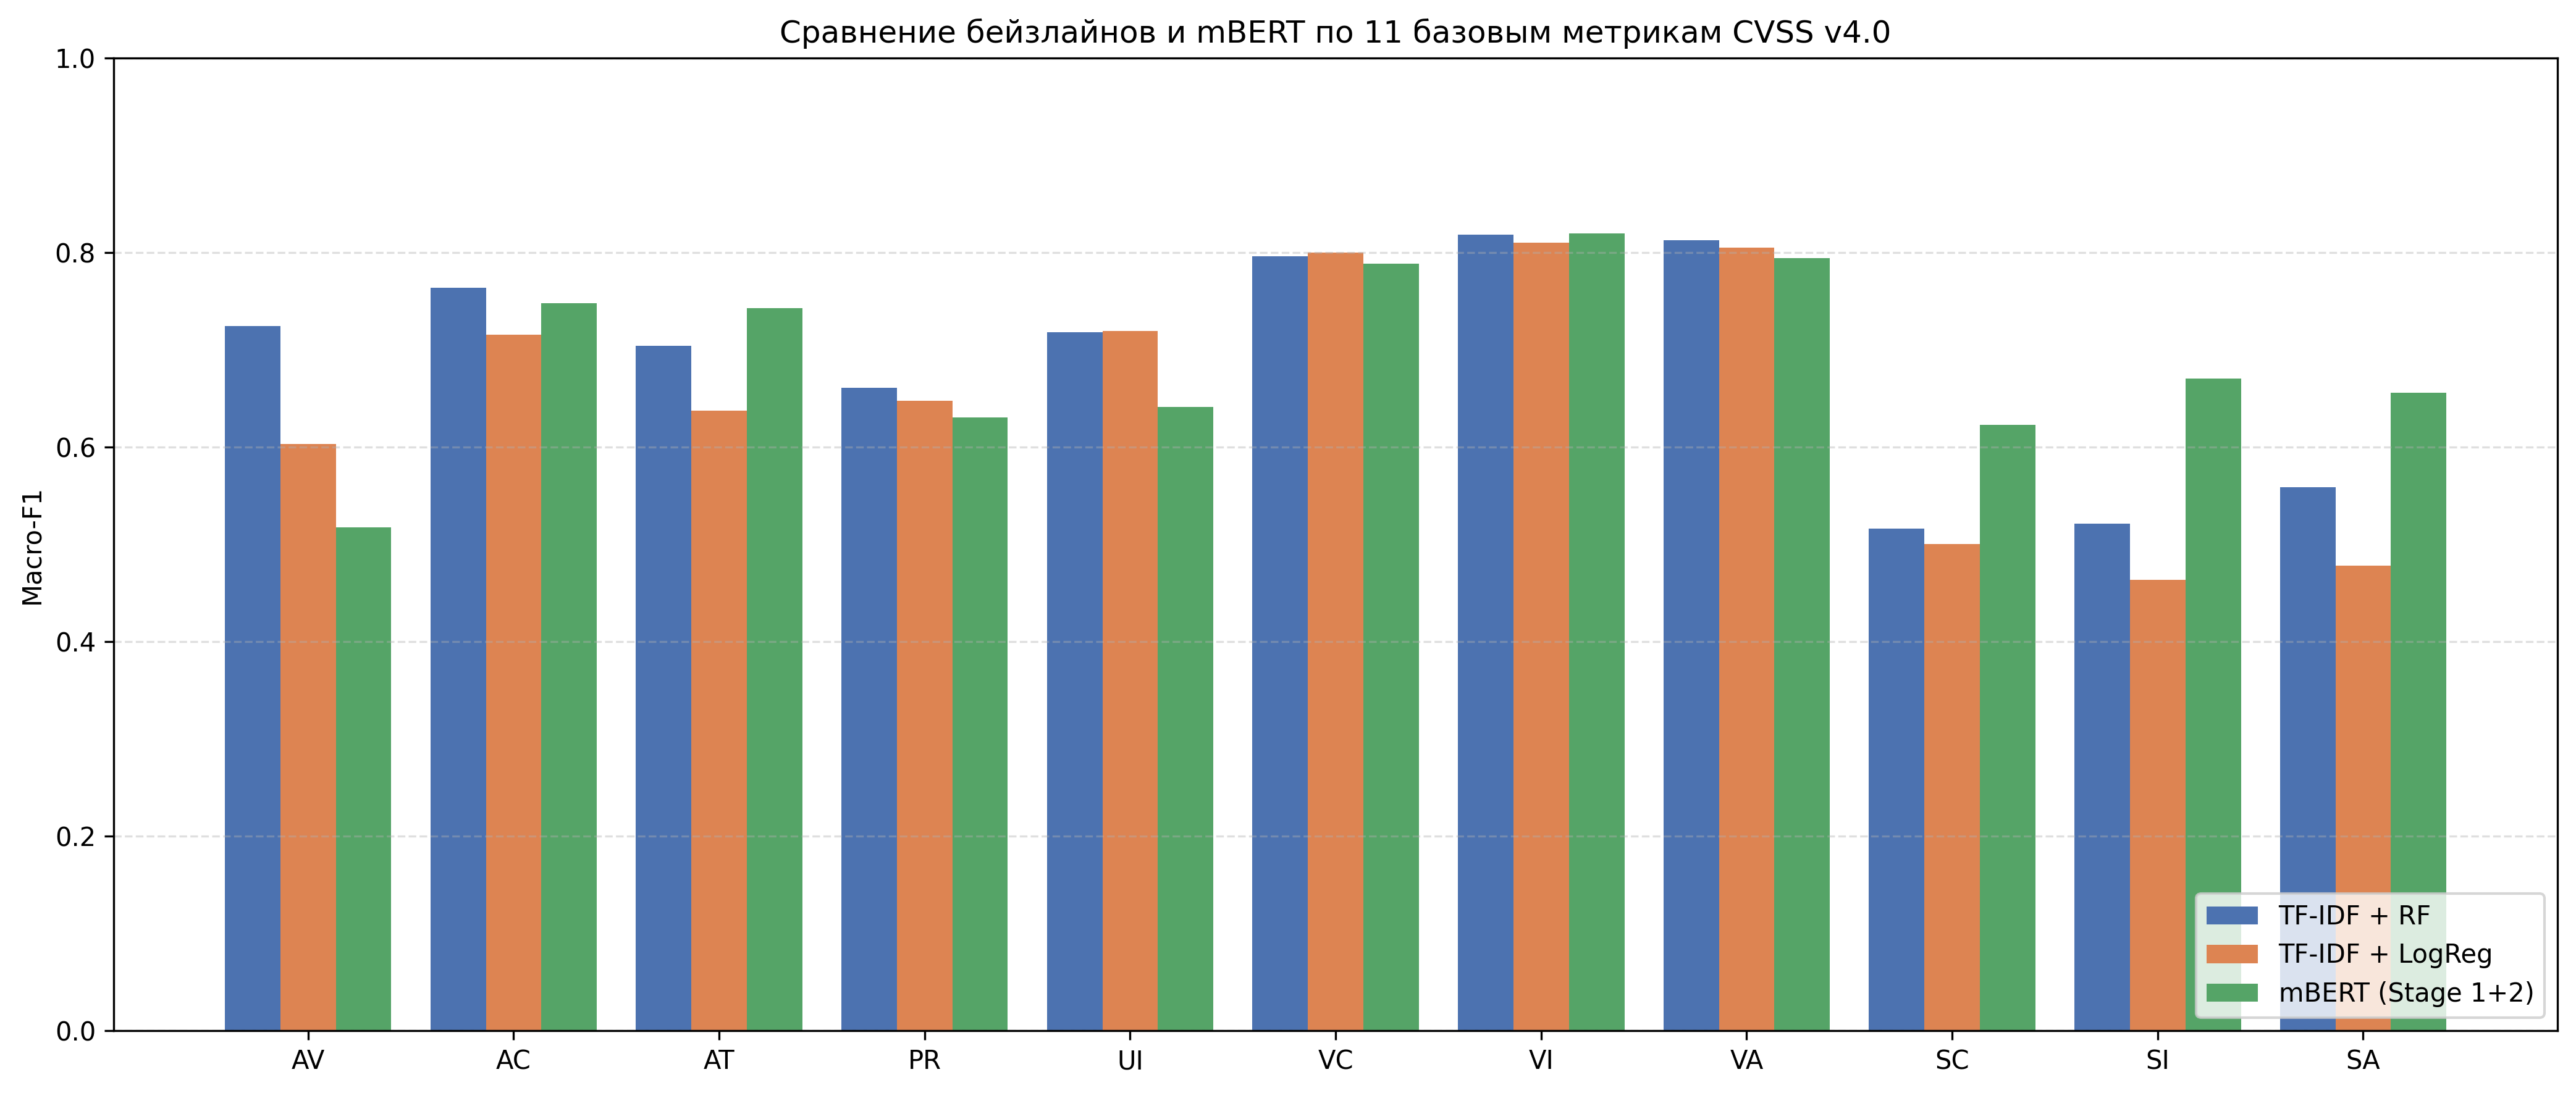

In [6]:
metrics_order = list(BASE_VECTOR_METRICS)
rf_f1   = [rf_result['per_metric'][m]['f1_macro']  for m in metrics_order]
lr_f1   = [lr_result['per_metric'][m]['f1_macro']  for m in metrics_order]
mb_f1   = [mbert_per_metric.get(m, np.nan)         for m in metrics_order]

x = np.arange(len(metrics_order))
width = 0.27

fig, ax = plt.subplots(figsize=(14, 6), dpi=300)
ax.bar(x - width, rf_f1, width, label='TF-IDF + RF', color='#4c72b0')
ax.bar(x,         lr_f1, width, label='TF-IDF + LogReg', color='#dd8452')
ax.bar(x + width, mb_f1, width, label='mBERT (Stage 1+2)', color='#55a467')
ax.set_xticks(x)
ax.set_xticklabels(metrics_order)
ax.set_ylim(0, 1)
ax.set_ylabel('Macro-F1')
ax.set_title('Сравнение бейзлайнов и mBERT по 11 базовым метрикам CVSS v4.0')
ax.grid(True, axis='y', linestyle='--', alpha=0.4)
ax.legend(loc='lower right')
fig.tight_layout()

out_png = ROOT / 'reports/figures/baseline_comparison.png'
out_png.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out_png, dpi=300, bbox_inches='tight')
print('Сохранено:', out_png)
plt.show()